# Learning how to use appletree for simulations
Learn how to:
1. set the list of parameters (some sort of config file I guess)
2. sample parameters from prior
    - `sample_init`: 
    - `sample_prior`: 
3. what really comes out? set of events or histogram or what?

Can use `multiple_simulations` to one shot simulate many sets of events, but seems like only with same parameter values

Pueh Leng Tan, 10 March 2026

In [1]:
import os
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import jax.numpy as jnp
import multihist as mh
import scipy.stats as sps

import appletree as apt
from appletree.utils import get_file_path

XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform
Using aptext package from https://github.com/XENONnT/applefiles


In [2]:
# constrain the GPU memory usage

apt.set_gpu_memory_usage(0.2)

## Define component

### ComponentSim

In [3]:
# The components is associated with bins, so first we load bins
data = pd.read_csv(get_file_path("data_Rn220.csv"))
bins_cs1, bins_cs2 = apt.utils.get_equiprob_bins_2d(
    data[["cs1", "cs2"]].to_numpy(),
    [15, 15],
    order=[0, 1],
    x_clip=[0, 100],
    y_clip=[1e2, 1e4],
    which_np=jnp,
)

In [4]:
get_file_path("data_Rn220.csv") # 2k events, (index, cs1, cs2)

'/home/puehlengt/appletree/appletree/data/data_Rn220.csv'

In [5]:
# Initialize component
er = apt.ERBand(bins=[bins_cs1, bins_cs2], bins_type="irreg")

In [6]:
# Deduce the workflow(datastructure)
er.deduce(data_names=["cs1", "cs2"], func_name="simulate")  # 'eff'(efficiency) is always simulated
er.rate_name = "er_rate"  # also we have to specify a normalization factor of the component

# Compile ER script
# This is meta-programing because  appletree can generate codes dynamically
er.compile()

ERBand_llh's map s2_cut_acc is using the parameter s2_cut_acc_sigma.
ERBand_llh's map s1_cut_acc is using the parameter s1_cut_acc_sigma.
ERBand_llh's map s1_eff_3f is static and not using any parameter.


In [7]:
# For reference, this is the compiled code, the function is stored in appletree.share._cached_functions
print(er.code)

from functools import partial
from jax import jit
from appletree.plugins import PositionSpectra
from appletree.plugins import UniformEnergySpectra
from appletree.plugins import RecombFluct
from appletree.plugins import mTI
from appletree.plugins import Quanta
from appletree.plugins import TrueRecombER
from appletree.plugins import IonizationER
from appletree.plugins import DriftLoss
from appletree.plugins import RecombinationER
from appletree.plugins import S2LCE
from appletree.plugins import ElectronDrifted
from appletree.plugins import S2PE
from appletree.plugins import S2
from appletree.plugins import S1LCE
from appletree.plugins import PhotonDetection
from appletree.plugins import S1PE
from appletree.plugins import S1
from appletree.plugins import S2CutAccept
from appletree.plugins import S1CutAccept
from appletree.plugins import S1ReconEff
from appletree.plugins import S2Threshold
from appletree.plugins import PositionRecon
from appletree.plugins import S2Correction
from appletree

## Load parameters
Is the only way to vary the set of parameters changing them to 'fixed' in the config file?  
Guess I can't just delete things cause I'd still have to define the default value.

So it means this config file lists all the possible params I can have in the ER model? (23 parameters)

How to comment out chunks in this .json file? \\* *\ doesn't work on chunks.
Can use `set_parameter`?

In [8]:
# Of course we have to load parameters(and their priors) in simulation

# '/home/puehlengt/appletree/appletree/parameters/er.json'
#par_manager = apt.Parameter(get_file_path("er.json"))
par_manager = apt.Parameter(get_file_path("my_er.json"))

par_manager.sample_init()
parameters = par_manager.get_all_parameter() # dictionary of parameters

In [9]:
par_manager.sample_prior()
parameters = par_manager.get_all_parameter() # dictionary of parameters
parameters

{'w': 0.0137,
 'fano': 0.059,
 'gas_gain': 31.3,
 'drift_velocity': 0.0677,
 's2_threshold': 500.0,
 'field': 23.0,
 'nex_ni_ratio': np.float64(0.15748705213868802),
 'g1': np.float64(0.15144381954891098),
 'g2': np.float64(15.488399896026364),
 'p_dpe': np.float64(0.21195798225044407),
 'elife_sigma': np.float64(-0.004097058322788143),
 's1_eff_3f_sigma': np.float64(0.6794701936891369),
 's1_cut_acc_sigma': np.float64(-0.015711681061735885),
 's2_cut_acc_sigma': np.float64(-0.9046649771611709),
 'py0': np.float64(0.12598610934077797),
 'py1': np.float64(44.11035911948911),
 'py2': np.float64(-0.2622987503540749),
 'py3': np.float64(1.221501566469572),
 'py4': np.float64(0.881886521808833),
 'rf0': np.float64(0.02557366370601848),
 'rf1': np.float64(0.21887302070247613),
 'ac_rate': np.float64(12.902971398825713),
 'er_rate': np.float64(1993.265303496858)}

In [10]:
par_manager.sample_init()
parameters = par_manager.get_all_parameter() # dictionary of parameters
parameters

{'w': 0.0137,
 'fano': 0.059,
 'gas_gain': 31.3,
 'drift_velocity': 0.0677,
 's2_threshold': 500.0,
 'field': 23.0,
 'nex_ni_ratio': np.float64(0.11042969564143447),
 'g1': np.float64(0.15229806917076205),
 'g2': np.float64(17.094657620556923),
 'p_dpe': np.float64(0.20315709557939976),
 'elife_sigma': np.float64(0.024217089503230142),
 's1_eff_3f_sigma': np.float64(0.623962984982381),
 's1_cut_acc_sigma': np.float64(0.23077711075748966),
 's2_cut_acc_sigma': np.float64(-1.0491459898827908),
 'py0': np.float64(0.14350221875088873),
 'py1': np.float64(42.71320231350306),
 'py2': np.float64(-0.2911771648691496),
 'py3': np.float64(0.8316922901343702),
 'py4': np.float64(0.4039321753224532),
 'rf0': np.float64(0.020151699470382662),
 'rf1': np.float64(0.3744226460459685),
 'ac_rate': np.float64(14.88408947760956),
 'er_rate': np.float64(1989.2913884016423)}

In [11]:
#batch_size = int(1e5) # we're gonna fit <1e5 events right?
batch_size = int(5e3) # testing
key = apt.randgen.get_key(seed=137)

par_manager.sample_prior() # sample params from prior
parameters = par_manager.get_all_parameter() # dictionary of parameters
key, (cs1, cs2, eff) = er.simulate(key, batch_size, parameters)
n = sps.poisson.rvs(mu=parameters["er_rate"])

In [13]:
np.unique(eff), np.sum(eff)

(array([0., 1.], dtype=float32), Array(4711., dtype=float32))

In [19]:
np.random.choice??

Signature: np.random.choice(a, size=None, replace=True, p=None)
Docstring:
choice(a, size=None, replace=True, p=None)

Generates a random sample from a given 1-D array

.. versionadded:: 1.7.0

.. note::
    New code should use the `~numpy.random.Generator.choice`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

.. warning::
    This function uses the C-long dtype, which is 32bit on windows
    and otherwise 64bit on 64bit platforms (and 32bit on 32bit ones).
    Since NumPy 2.0, NumPy's default integer is 32bit on 32bit platforms
    and 64bit on 64bit platforms.


Parameters
----------
a : 1-D array-like or int
    If an ndarray, a random sample is generated from its elements.
    If an int, the random sample is generated as if it were ``np.arange(a)``
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are drawn.  Default is None, in which case a


Text(0, 0.5, 'cs2 [PE]')

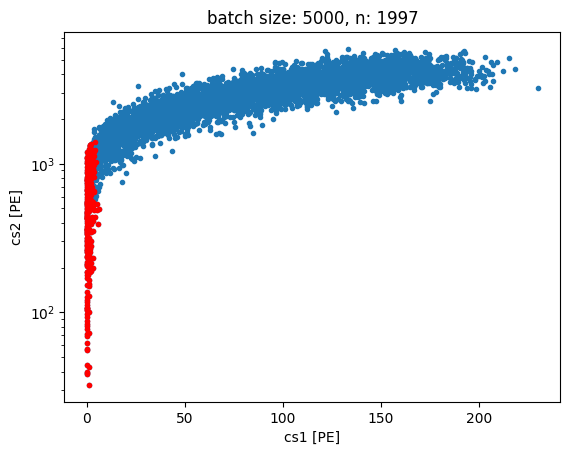

In [14]:
plt.plot(cs1, cs2, '.')
plt.plot(cs1[~eff.astype(bool)], cs2[~eff.astype(bool)], 'r.')
plt.yscale('log')
plt.title(f'batch size: {batch_size}, n: {n}')
plt.xlabel('cs1 [PE]')
plt.ylabel('cs2 [PE]')

In [15]:
raise

RuntimeError: No active exception to reraise

In [ ]:
par_manager.sample_prior() # sample params from prior
parameters = par_manager.get_all_parameter() # dictionary of parameters
key, (cs1, cs2, eff) = er.simulate(key, batch_size, parameters)

In [ ]:
par_manager.sample_prior() # sample params from prior
parameters = par_manager.get_all_parameter() # dictionary of parameters
key, (cs1, cs2, eff) = er.simulate(key, batch_size, parameters)

In [ ]:
batch_size = int(1e4) # testing
key = apt.randgen.get_key(seed=137)
key, (cs1, cs2, eff) = er.multiple_simulations(key, batch_size, parameters, times=3) # simulate multiple sets of events with same parameter values

In [ ]:
type(cs1), cs1.shape

## Simulation

In [ ]:
# Really do the simulation

batch_size = int(1e6) # number of events that goes into histogram (also length of cs1, cs2, eff)
key = apt.randgen.get_key(seed=137)

key, (cs1, cs2, eff) = er.simulate(key, batch_size, parameters) # cs1, cs2, eff are all 1d jax arrays of length batch_size

In [ ]:
er.simulate??

In [ ]:
print(er.code)


In [ ]:
cs1, len(cs1), type(cs1), type(cs2), type(eff)

In [ ]:
len(eff), np.sum(eff), np.unique(eff)

In [ ]:
plt.plot(cs1[:1000], cs2[:1000], ".")
plt.yscale("log")

In [ ]:
# Just to show the histogram

h, be = jnp.histogramdd(
    jnp.asarray([cs1, cs2]).T,
    bins=(jnp.linspace(0, 100, 101), jnp.logspace(2.5, 4.1, 81)),
    weights=eff,
)

h = mh.Histdd.from_histogram(np.array(h), be, axis_names=["cs1", "cs2"])
h.plot(norm=LogNorm())
plt.yscale("log")
plt.show()

## Simulation and make equiprob hist

In [ ]:
# Actually `simulate_hist` is just a wrapper of `simulate`
# it calls `simulate` and histograms the MC events

batch_size = int(1e6)
key = apt.randgen.get_key(seed=137)
par_manager.sample_prior() # sample params from prior
parameters = par_manager.get_all_parameter() # dictionary of parameters
key, h = er.simulate_hist(key, batch_size, parameters) # h is a jax array of shape (

In [ ]:
bins_cs1.shape, bins_cs2.shape, h.shape

In [ ]:
np.sum(h), parameters['er_rate'], np.sum(h)==parameters['er_rate']

In [ ]:
parameters

In [ ]:
# must i re-seed this each time?


In [ ]:
apt.utils.plot_irreg_histogram_2d(bins_cs1, bins_cs2, h, density=False)
plt.yscale("log")
plt.ylim(5e2, 1e4)
plt.show()

In [ ]:
h = ac.simulate_hist(parameters)

In [ ]:
apt.utils.plot_irreg_histogram_2d(bins_cs1, bins_cs2, h, density=False)
plt.yscale("log")
plt.ylim(5e2, 1e4)
plt.show()

## Speed test

In [ ]:
@apt.utils.timeit
def test(key, batch_size, parameters):
    return er.simulate_hist(key, batch_size, parameters)

In [ ]:
@apt.utils.timeit
def benchmark():
    key = apt.randgen.get_key()
    for _ in range(100):
        key, _ = test(key, int(1e6), parameters)

In [ ]:
benchmark()